In [27]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import joblib

In [28]:
df=pd.read_csv(r"C:\Users\Dell\Desktop\Dhara\backend\ml\Crop_recommendation.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [29]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.shape

(2200, 8)

In [33]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


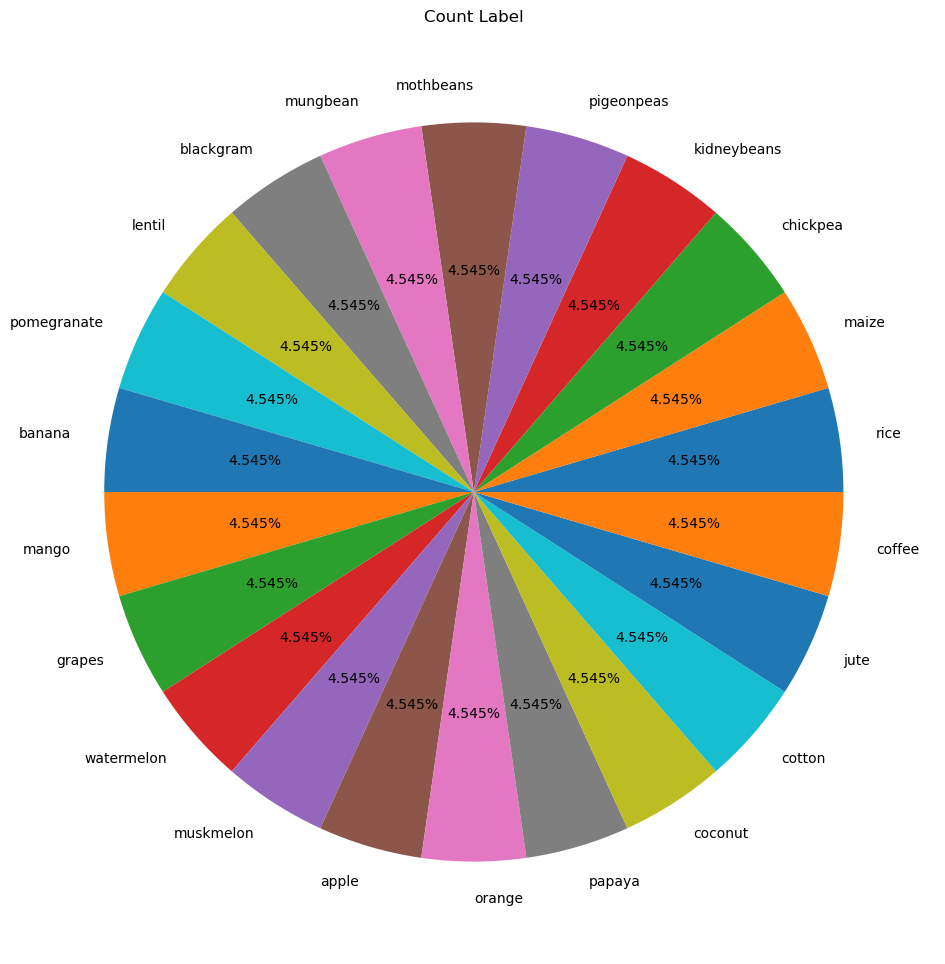

In [34]:
plt.figure(figsize=(12,12))
plt.pie(df.label.value_counts(),labels=df.label.value_counts().index,autopct='%.3f%%')
plt.title("Count Label")
plt.show()

In [35]:
le=LabelEncoder()

In [36]:
df["le_label"]=le.fit_transform(df['label'])

In [37]:
df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall','le_label']].corr()

,N,P,K,temperature,humidity,ph,rainfall,le_label
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020,-0.031130
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839,-0.491006
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461,-0.346417
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084,0.113606
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423,0.193911
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069,-0.012253
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000,0.045611
le_label,-0.031130,-0.491006,-0.346417,0.113606,0.193911,-0.012253,0.045611,1.000000


In [38]:
#Train Test Split
x=df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y=df['le_label']

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42,shuffle=True,stratify=y)

In [40]:
#LogisticRegreesion Model
log=LogisticRegression()

In [41]:
log.fit(x_train,y_train)

c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [42]:
pred=log.predict(x_test)
print(classification_report(pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.65      0.68      0.67        19
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.97        19
           5       1.00      1.00      1.00        20
           6       1.00      0.80      0.89        25
           7       1.00      1.00      1.00        20
           8       1.00      0.87      0.93        23
           9       1.00      1.00      1.00        20
          10       0.85      0.89      0.87        19
          11       0.75      0.83      0.79        18
          12       1.00      1.00      1.00        20
          13       0.75      0.75      0.75        20
          14       0.95      1.00      0.97        19
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

In [43]:
#xgboost model
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=22, random_state=42)

In [44]:
param_grid = {
    'n_estimators': [50, 100],        
    'max_depth': [3, 6, 9],           
    'learning_rate': [0.01, 0.1],     
    'subsample': [0.8, 1.0]           
}

In [45]:
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1)

In [46]:
grid_search.fit(x_train, y_train)
best_model = grid_search.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [47]:
y_pred = best_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.85      0.92        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       0.91      1.00      0.95        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

In [48]:
df['le_label'].unique()

array([20, 11,  3,  9, 18, 13, 14,  2, 10, 19,  1, 12,  7, 21, 15,  0, 16,
       17,  4,  6,  8,  5])

In [49]:
joblib.dump(best_model, 'xgboost_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [50]:
sample = [[90, 40, 40, 25, 80, 6.5, 200]]

pred = best_model.predict(sample)

crop = le.inverse_transform(pred)

print("Predicted crop:", crop[0])


Predicted crop: jute


In [51]:
df[(df['rainfall'] > 180) & (df['humidity'] > 75)].head()


,N,P,K,temperature,humidity,ph,rainfall,label,le_label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20
